# exp033 — Significance test: NCC difference between Ensemble and VIDS

Both models are evaluated on the same 1226 image/phase pairs → **paired** comparison.  
NCC is bounded and potentially non-normal → primary test is the **Wilcoxon signed-rank test**.  
Paired t-test and a permutation test are included for completeness.

**Prerequisite:** run the save cell in exp030 and exp032 first to generate `df_ens_ncc.csv` and `df_vids_ncc.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

EXP_DIR = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/'

df_ens  = pd.read_csv(EXP_DIR + 'df_ens_ncc.csv')
df_vids = pd.read_csv(EXP_DIR + 'df_vids_ncc.csv')

print('Ensemble rows:', len(df_ens))
print('VIDS rows:    ', len(df_vids))

Ensemble rows: 1226
VIDS rows:     1226


In [2]:
# Merge on file + phase so each row is a matched pair
df = pd.merge(
    df_ens[['file', 'phase', 'age_group', 'ncc']].rename(columns={'ncc': 'ncc_ens'}),
    df_vids[['file', 'phase', 'ncc']].rename(columns={'ncc': 'ncc_vids'}),
    on=['file', 'phase'],
    how='inner'
)
df['ncc_diff'] = df['ncc_vids'] - df['ncc_ens']  # positive = VIDS better

print(f'Matched pairs: {len(df)}')
print(f'Unmatched Ensemble: {len(df_ens) - len(df)}')
print(f'Unmatched VIDS:     {len(df_vids) - len(df)}')
df.head(3)

Matched pairs: 1226
Unmatched Ensemble: 0
Unmatched VIDS:     0


,file,phase,age_group,ncc_ens,ncc_vids,ncc_diff
0,CR32a7558-CR32a7585-000056.h5,ed,infant,0.369348,0.694531,0.325183
1,CR32a7558-CR32a7585-000056.h5,es,infant,0.287473,0.564339,0.276866
2,CR32a7558-CR32a9ab2-000062.h5,ed,infant,0.260538,0.588481,0.327943


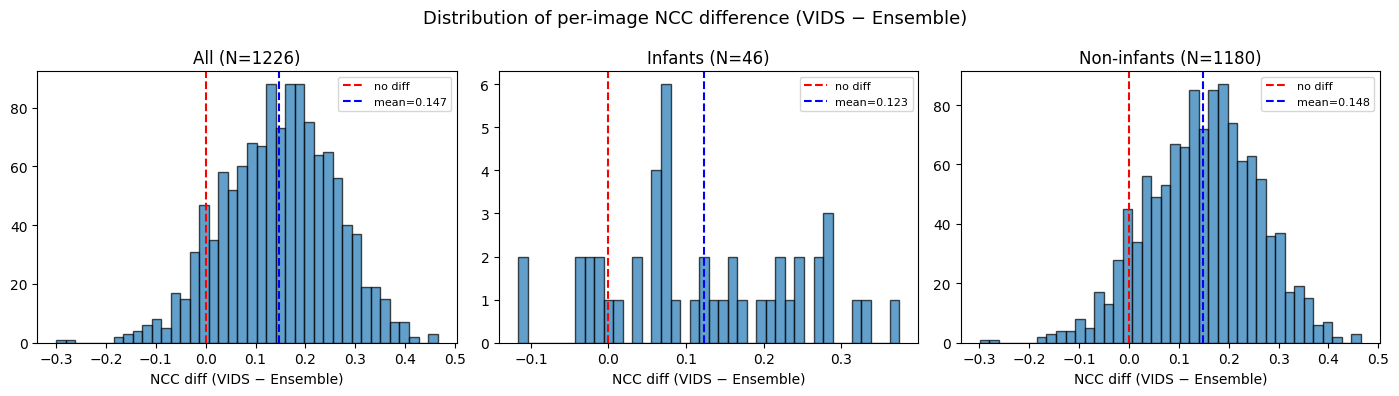

All: Shapiro-Wilk W=0.9969, p=0.01509
Infants: Shapiro-Wilk W=0.9742, p=0.3936
Non-infants: Shapiro-Wilk W=0.9967, p=0.01514


In [3]:
# Normality check on differences (informs test choice)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

groups = [
    ('All',         df),
    ('Infants',     df[df['age_group'] == 'infant']),
    ('Non-infants', df[df['age_group'] == 'non-infant']),
]

for ax, (label, sub) in zip(axes, groups):
    ax.hist(sub['ncc_diff'], bins=40, edgecolor='k', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='no diff')
    ax.axvline(sub['ncc_diff'].mean(), color='blue', linestyle='--', label=f'mean={sub["ncc_diff"].mean():.3f}')
    ax.set_title(f'{label} (N={len(sub)})')
    ax.set_xlabel('NCC diff (VIDS − Ensemble)')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of per-image NCC difference (VIDS − Ensemble)', fontsize=13)
plt.tight_layout()
plt.show()

# Shapiro-Wilk on a subsample (Shapiro requires N ≤ 5000)
for label, sub in groups:
    sample = sub['ncc_diff'].sample(min(len(sub), 5000), random_state=0)
    sw_stat, sw_p = stats.shapiro(sample)
    print(f'{label}: Shapiro-Wilk W={sw_stat:.4f}, p={sw_p:.4g}')

In [4]:
def run_tests(sub, label):
    ens  = sub['ncc_ens'].values
    vids = sub['ncc_vids'].values
    diff = sub['ncc_diff'].values
    n    = len(sub)

    # --- Wilcoxon signed-rank (primary: paired, non-parametric) ---
    w_stat, w_p = stats.wilcoxon(vids, ens, alternative='two-sided')
    # rank-biserial correlation as effect size for Wilcoxon
    r_rb = 1 - (2 * w_stat) / (n * (n + 1) / 2)

    # --- Paired t-test (secondary) ---
    t_stat, t_p = stats.ttest_rel(vids, ens)
    # Cohen's d for paired data
    cohens_d = diff.mean() / diff.std(ddof=1)

    # --- Permutation test (label-swap on pairs) ---
    rng = np.random.default_rng(42)
    obs_mean_diff = diff.mean()
    n_perm = 10_000
    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        signs = rng.choice([-1, 1], size=n)
        perm_diffs[i] = (diff * signs).mean()
    perm_p = np.mean(np.abs(perm_diffs) >= np.abs(obs_mean_diff))

    print(f'\n=== {label} (N={n}) ===')
    print(f'  Ensemble NCC:  {ens.mean():.4f} ± {ens.std():.4f}')
    print(f'  VIDS NCC:      {vids.mean():.4f} ± {vids.std():.4f}')
    print(f'  Mean diff:     {obs_mean_diff:.4f} (VIDS − Ensemble)')
    print(f'  Wilcoxon:      W={w_stat:.1f},  p={w_p:.4g},  r_rb={r_rb:.3f}')
    print(f'  Paired t-test: t={t_stat:.3f}, p={t_p:.4g},  Cohen\'s d={cohens_d:.3f}')
    print(f'  Permutation:   p={perm_p:.4g}  (10 000 label-swap permutations)')


for label, sub in groups:
    run_tests(sub, label)


=== All (N=1226) ===
  Ensemble NCC:  0.3551 ± 0.1583
  VIDS NCC:      0.5022 ± 0.1442
  Mean diff:     0.1471 (VIDS − Ensemble)
  Wilcoxon:      W=24937.0,  p=2.055e-176,  r_rb=0.934
  Paired t-test: t=46.449, p=1.918e-272,  Cohen's d=1.327
  Permutation:   p=0  (10 000 label-swap permutations)

=== Infants (N=46) ===
  Ensemble NCC:  0.3965 ± 0.1750
  VIDS NCC:      0.5193 ± 0.1274
  Mean diff:     0.1228 (VIDS − Ensemble)
  Wilcoxon:      W=78.0,  p=1.886e-08,  r_rb=0.856
  Paired t-test: t=6.872, p=1.58e-08,  Cohen's d=1.013
  Permutation:   p=0  (10 000 label-swap permutations)

=== Non-infants (N=1180) ===
  Ensemble NCC:  0.3535 ± 0.1574
  VIDS NCC:      0.5015 ± 0.1448
  Mean diff:     0.1480 (VIDS − Ensemble)
  Wilcoxon:      W=22305.0,  p=1.07e-170,  r_rb=0.936
  Paired t-test: t=46.059, p=8.32e-266,  Cohen's d=1.341
  Permutation:   p=0  (10 000 label-swap permutations)


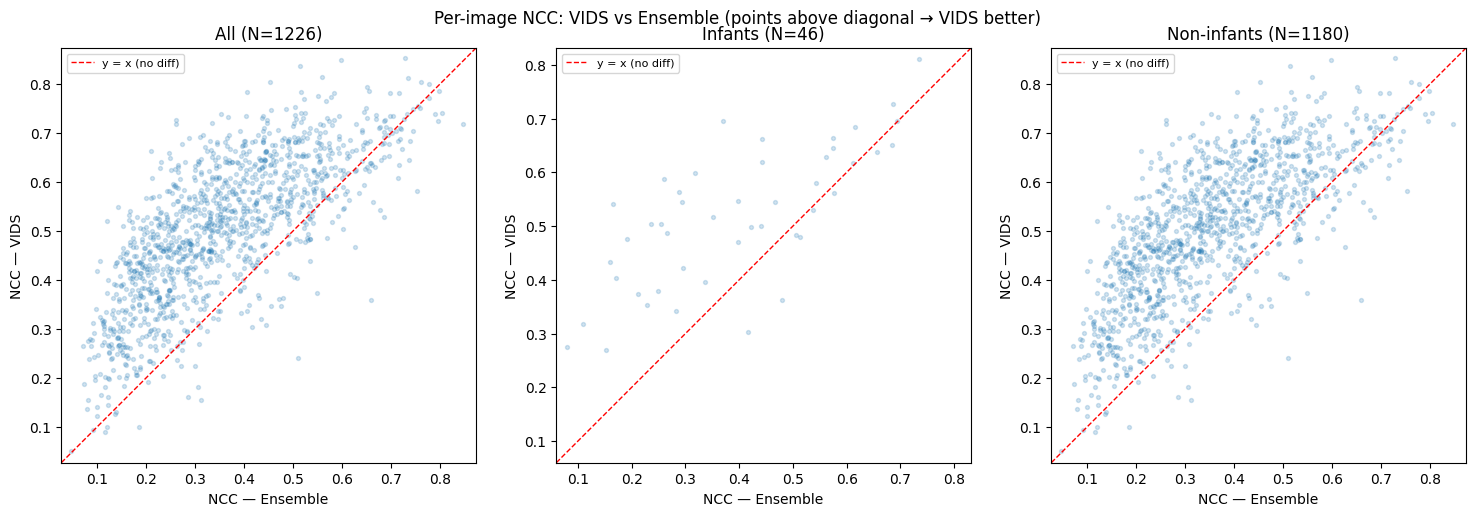

In [5]:
# Visual summary: paired NCC values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, sub) in zip(axes, groups):
    ax.scatter(sub['ncc_ens'], sub['ncc_vids'], alpha=0.2, s=8)
    lims = [min(sub['ncc_ens'].min(), sub['ncc_vids'].min()) - 0.02,
            max(sub['ncc_ens'].max(), sub['ncc_vids'].max()) + 0.02]
    ax.plot(lims, lims, 'r--', lw=1, label='y = x (no diff)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('NCC — Ensemble')
    ax.set_ylabel('NCC — VIDS')
    ax.set_title(f'{label} (N={len(sub)})')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

fig.suptitle('Per-image NCC: VIDS vs Ensemble (points above diagonal → VIDS better)', fontsize=12)
plt.tight_layout()
plt.show()